In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats

from data.loader import fetch_prices
from pairs.selection import find_pairs, compute_spread
from pairs.metrics import fit_ou

## Configuration

In [2]:
TICKERS = ['XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLRE']
START = '2010-01-01'
END   = '2024-12-31'
P_THRESHOLD = 0.05
INSPECT_PAIR = None  # set to ('TICK1', 'TICK2') to pin a specific pair

## What is the Ornstein-Uhlenbeck process?

The Ornstein-Uhlenbeck process is a stochastic model for a value that gets pulled toward a long-run mean over time, with random noise added continuously. It is the theoretical foundation of pairs trading: if two stocks are cointegrated, their spread behaves approximately like an OU process.

The equation is:

    dX = theta * (mu - X) * dt + sigma * dW

Term by term:
- **dX** is the change in the spread over a small time interval.
- **theta** is the mean reversion speed. Higher theta means faster reversion. At theta = 0 there is no pull and the process is a pure random walk.
- **mu** is the long-run mean the spread reverts toward.
- **(mu - X)** is the current displacement from the mean. The larger the displacement, the stronger the restoring force.
- **sigma** is the scale of the noise term.
- **dW** is a standard Brownian motion increment, the noise term.

When the pull (theta) is strong relative to the noise (sigma), the spread stays bounded and is predictable enough to trade. When noise dominates, the spread wanders and entries become unreliable.

The OU model is what lets us compute the half-life analytically. The half-life tells us how long a typical trade should take to become profitable, which sets the z-score window and the expected holding period for each position.

## 1. Load Data and Select Pair

In [3]:
prices = fetch_prices(TICKERS, START, END)
pairs  = find_pairs(prices, p_threshold=P_THRESHOLD)

if INSPECT_PAIR:
    t1, t2 = INSPECT_PAIR
    match = next((p for p in pairs if set(p['pair']) == {t1, t2}), None)
    hedge_ratio = match['hedge_ratio'] if match else 1.0
else:
    best = pairs[0]
    t1, t2 = best['pair']
    hedge_ratio = best['hedge_ratio']

spread = compute_spread(prices, t1, t2, hedge_ratio)
print(f"Pair: {t1}/{t2}  hedge ratio: {hedge_ratio:.4f}")

Pair: XLP/XLU  hedge ratio: 2.1292


## 2. Fit the OU Model

Theta, mu, and sigma are not directly observable. They are estimated from the data using a simple regression.

The OU process, when sampled at daily intervals, is equivalent to an AR(1):

    X_today = a + b * X_yesterday + noise

This is a linear regression of today's spread on yesterday's spread. The slope b maps to theta as:

    b = exp(-theta)  so  theta = -log(b)

When b is close to 1, theta is small and reversion is slow. As b approaches 0, theta grows and reversion becomes faster.

The **half-life** follows from theta:

    half_life = log(2) / theta

This is the number of days it takes, on average, for the spread to cover half the distance back to its mean from any starting point.

In [4]:
ou = fit_ou(spread)

print(f"AR(1) coefficient b:   {ou['b']:.4f}")
print(f"  (must be in (0,1) for mean reversion; close to 1 = slow reversion)")
print()
print(f"theta (reversion speed): {ou['theta']:.4f} per day")
print(f"mu    (long-run mean):   {ou['mu']:.4f}")
print(f"sigma (daily volatility):{ou['sigma']:.4f}")
print()
print(f"Half-life:  {ou['half_life']:.1f} days")
print(f"R-squared:  {ou['r_squared']:.4f}  (fit quality of the AR(1) regression)")
print(f"Valid pair: {ou['is_valid']}")

AR(1) coefficient b:   0.9885
  (must be in (0,1) for mean reversion; close to 1 = slow reversion)

theta (reversion speed): 0.0115 per day
mu    (long-run mean):   0.7408
sigma (daily volatility):0.3927

Half-life:  60.2 days
R-squared:  0.9771  (fit quality of the AR(1) regression)
Valid pair: True


> **Observations - OU Parameters**
>
> Half-life is 60.2 days, right at the upper edge of the workable range. That means a trade opened at z=2 should take roughly 60 days to reach z=1, and a full reversion to the mean takes around 4-5 months on average. Trades will be slow to resolve. The z-score window is set to match (60 days), so the signal is calibrated to the actual reversion speed.
>
> The AR(1) coefficient b=0.9885 confirms the slow reversion. A value near 1 means the spread retains almost all of its deviation from one day to the next, pulling back only about 1.15% per day on average (theta=0.0115). This is not a fast mean-reverting pair.
>
> R-squared of 0.9771 is high. The AR(1) model explains 97.7% of the variance in the spread, which means the OU assumption is a good fit. The spread is well-described by the model.
>
> The combination of a long half-life and high R-squared means the signal is reliable but slow. Entries at z=2 are statistically justified; the question is whether the reversion actually completes within the test window before the relationship shifts. That is what the walk-forward test in notebook 05 will measure.

## 3. The AR(1) Regression

**What does the regression look like?**
Plotting X_today against X_yesterday produces a scatter of points that should cluster around a line with slope b. When b is below 1, the fitted line tilts below the 45-degree diagonal: high values of yesterday's spread predict a lower value today, and low values predict a higher one. That tilt is mean reversion made visible.

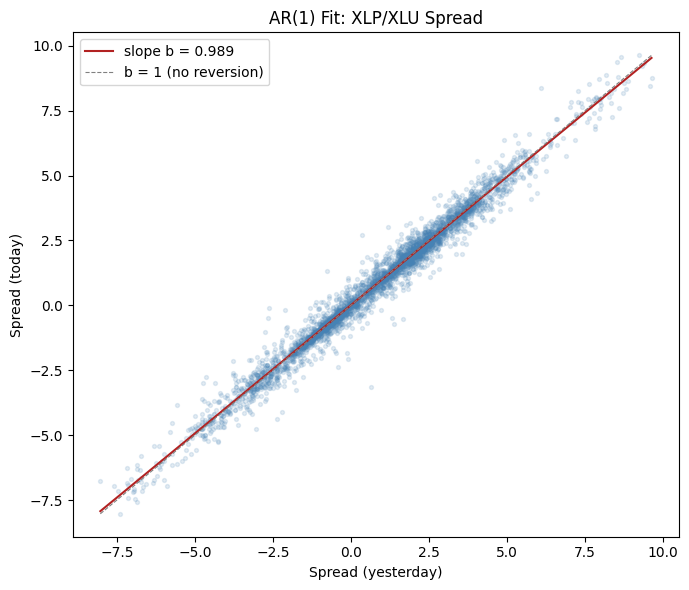

In [5]:
X_lag = spread.shift(1).dropna()
X_cur = spread.iloc[1:]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_lag, X_cur, alpha=0.15, s=8, color='steelblue')

# Plot the fitted AR(1) line
x_line = np.linspace(X_lag.min(), X_lag.max(), 100)
a_coef = ou['mu'] * (1 - ou['b'])  # recover intercept from mu and b
y_line = a_coef + ou['b'] * x_line
ax.plot(x_line, y_line, color='firebrick', linewidth=1.5, label=f"slope b = {ou['b']:.3f}")

# Also plot the 45-degree line for reference (b=1 = no mean reversion)
ax.plot(x_line, x_line, color='grey', linewidth=0.8, linestyle='--', label='b = 1 (no reversion)')

ax.set_xlabel('Spread (yesterday)')
ax.set_ylabel('Spread (today)')
ax.set_title(f'AR(1) Fit: {t1}/{t2} Spread')
ax.legend()
plt.tight_layout()
plt.show()

> **Observations: AR(1) Regression**
>
> The fitted line (slope b=0.9885) is nearly parallel to the 45-degree random walk line; the two are visually almost identical in the middle of the range and only diverge at the extremes. That is exactly what a slow-reverting process looks like: most days the spread barely moves, but at the tails there is a measurable pull back toward the mean. If the slope were 1.0, the lines would overlap completely and there would be no mean reversion at all.
>
> R²=0.9771 confirms the points cluster tightly around the fitted line. The AR(1) model captures almost all of the day-to-day spread dynamics. The scatter is not a cloud; it is a narrow band, which is reassuring. The spread is well-behaved and the regression is not being driven by outliers.

## 4. Half-Life Visualization

**What does half-life mean in practice?**
Starting from z=2, the expected decay path follows an exponential curve back to 0. The half-life is where that curve crosses z=1. After two half-lives the expected value is around z=0.5, and so on.

For a trade opened at z=2 with a half-life of 20 days: expect z=1 in roughly 20 days, z=0 in roughly 40-50 days. This is what sets the expected holding period, and why the z-score rolling window should match the half-life.

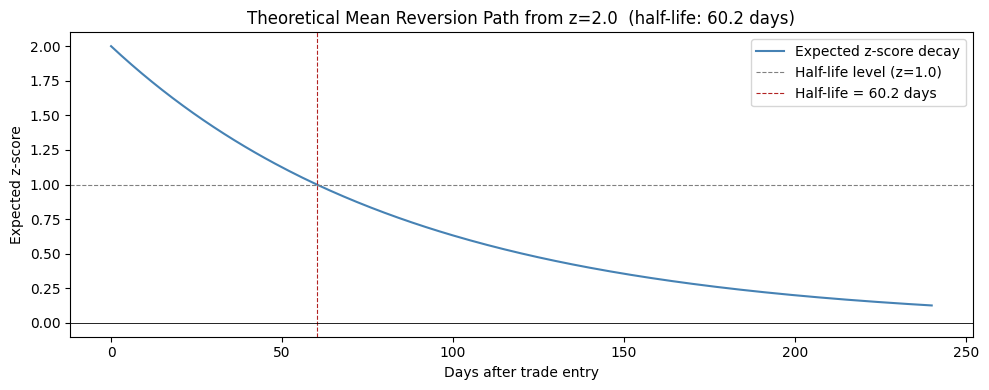

Starting at z=2.0, expected z-score after:
    5 days: 1.888
   10 days: 1.782
   60 days: 1.002
  120 days: 0.502
  180 days: 0.252


In [6]:
hl = ou['half_life']
theta = ou['theta']

days = np.arange(0, int(hl * 4) + 1)
# Expected value of the z-score starting at z0, decaying at rate theta
z0 = 2.0
expected_z = z0 * np.exp(-theta * days)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(days, expected_z, color='steelblue', linewidth=1.5, label='Expected z-score decay')
ax.axhline(z0 / 2, color='grey', linestyle='--', linewidth=0.8, label=f'Half-life level (z={z0/2:.1f})')
ax.axvline(hl, color='firebrick', linestyle='--', linewidth=0.8, label=f'Half-life = {hl:.1f} days')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xlabel('Days after trade entry')
ax.set_ylabel('Expected z-score')
ax.set_title(f'Theoretical Mean Reversion Path from z=2.0  (half-life: {hl:.1f} days)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Starting at z=2.0, expected z-score after:")
for d in [5, 10, int(hl), int(hl*2), int(hl*3)]:
    print(f"  {d:3d} days: {z0 * np.exp(-theta * d):.3f}")

> **Observations - Half-Life**
>
> At 60.2 days, this pair sits exactly at the upper boundary of the workable range. The decay table makes the implications concrete: after 5 days the z-score is still 1.888, barely moved. After 10 days it is 1.782. The spread is giving back almost nothing in the first two weeks of a trade.
>
> The full reversion story: z=1.0 by day 60, z=0.5 by day 120, z=0.25 by day 180. A position opened at z=2 and held to the exit threshold of z=0 takes on average 4-5 months to fully close. That is not a pairs trade in any conventional sense; it is closer to a multi-month directional bet that happens to be market-neutral.
>
> This lines up with what notebook 02 showed. The signal chart had long stretches where positions stayed open without resolving quickly. That slow turnover (53.9% of days in market across 171 trades over 14 years) is exactly what a 60-day half-life predicts. The math and the observed behavior are consistent.
>
> The practical concern is what can happen in 4-5 months. Macro regimes shift, corporate events occur, and the relationship that looked stable at entry may look different by the time reversion completes. A shorter half-life (15-30 days) would give the strategy much less exposure to that kind of drift. The economically motivated pairs tested from notebook 06 onward will have meaningfully shorter half-lives than this.

## 5. Residual Diagnostics

**Why check residuals?**
After stripping out the mean-reversion trend, the remaining residuals should be random white noise. Autocorrelation in the residuals means the AR(1) is missing structure; some predictable component is still left in the errors. Non-normality means the z-score thresholds may be miscalibrated: fatter tails than normal imply that ±3σ stops will be breached more often than the model expects.

Neither issue is fatal, but both are worth knowing when interpreting the results.

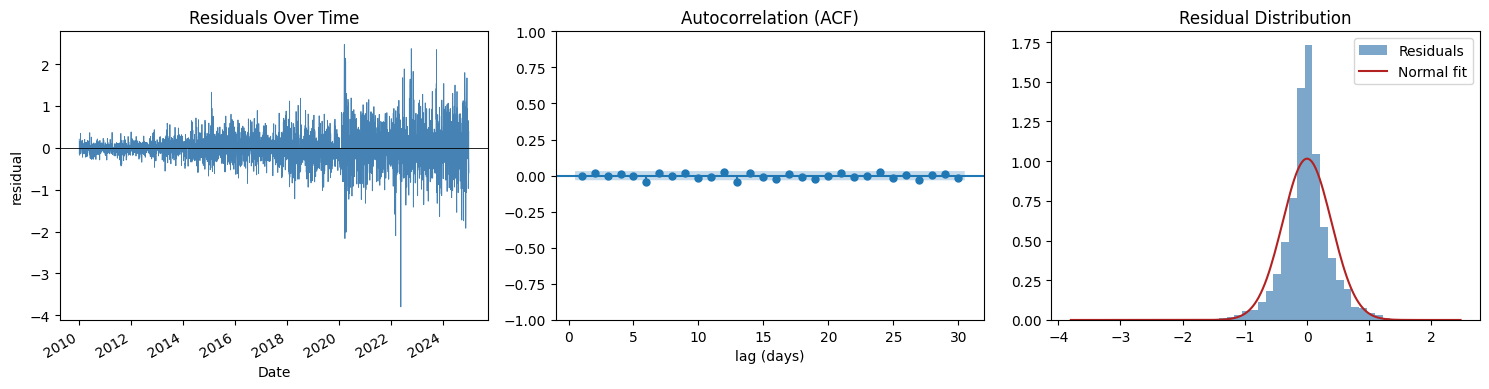

Normality test p-value: 0.0000  (not normal)


In [7]:
X_lag = spread.shift(1).dropna()
X_cur = spread.iloc[1:]
a_coef = ou['mu'] * (1 - ou['b'])
residuals = X_cur - (a_coef + ou['b'] * X_lag)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals over time
residuals.plot(ax=axes[0], color='steelblue', linewidth=0.6)
axes[0].axhline(0, color='k', linewidth=0.6)
axes[0].set_title('Residuals Over Time')
axes[0].set_ylabel('residual')

# Autocorrelation function
plot_acf(residuals, lags=30, ax=axes[1], title='Autocorrelation (ACF)', zero=False)
axes[1].set_xlabel('lag (days)')

# Histogram vs normal distribution
axes[2].hist(residuals, bins=50, density=True, color='steelblue', alpha=0.7, label='Residuals')
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
axes[2].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
             color='firebrick', linewidth=1.5, label='Normal fit')
axes[2].set_title('Residual Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

_, p_norm = stats.normaltest(residuals)
print(f"Normality test p-value: {p_norm:.4f}  ({'likely normal' if p_norm > 0.05 else 'not normal'})") 

> **Observations - Residual Diagnostics**
>
> **Residuals over time:** There is a clear volatility cluster around 2020-2022 where residuals spike to -4 and the variance visibly increases. Before 2018 the residuals look well-behaved, staying within roughly ±1. The basic OU model assumes constant volatility (constant sigma), so those years are a genuine model violation. The spread was noisier during that period than the model expects, which means z-score thresholds calibrated on the full period were too loose during the volatile stretch and too tight before it.
>
> **ACF chart:** All bars are essentially at zero across all 30 lags, well inside the confidence band. The AR(1) model has captured the autocorrelation structure completely. There is no remaining predictable pattern in the residuals.
>
> **Histogram:** The distribution is sharply peaked at zero with fat tails on both sides relative to the normal fit. The normality test confirms this (p=0.0000, strongly non-normal). Large residuals occur more often than a Gaussian model predicts. In practice this means the z=3 stop-loss will be triggered more frequently than the model implies, and trades that look like extreme outliers will happen regularly. The 2020 spike to nearly -4 seen in earlier charts is an example of exactly this.